In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
TARGET = "default.payment.next.month"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv(r'C:\Users\bibhu\Desktop\Credit Card Default Prediction\UCI_Credit_Card.csv')

In [5]:
df.head(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
df.shape

(30000, 25)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [8]:
df.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

In [9]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [10]:
df.nunique()

ID                            30000
LIMIT_BAL                        81
SEX                               2
EDUCATION                         7
MARRIAGE                          4
AGE                              56
PAY_0                            11
PAY_2                            11
PAY_3                            11
PAY_4                            11
PAY_5                            10
PAY_6                            10
BILL_AMT1                     22723
BILL_AMT2                     22346
BILL_AMT3                     22026
BILL_AMT4                     21548
BILL_AMT5                     21010
BILL_AMT6                     20604
PAY_AMT1                       7943
PAY_AMT2                       7899
PAY_AMT3                       7518
PAY_AMT4                       6937
PAY_AMT5                       6897
PAY_AMT6                       6939
default.payment.next.month        2
dtype: int64

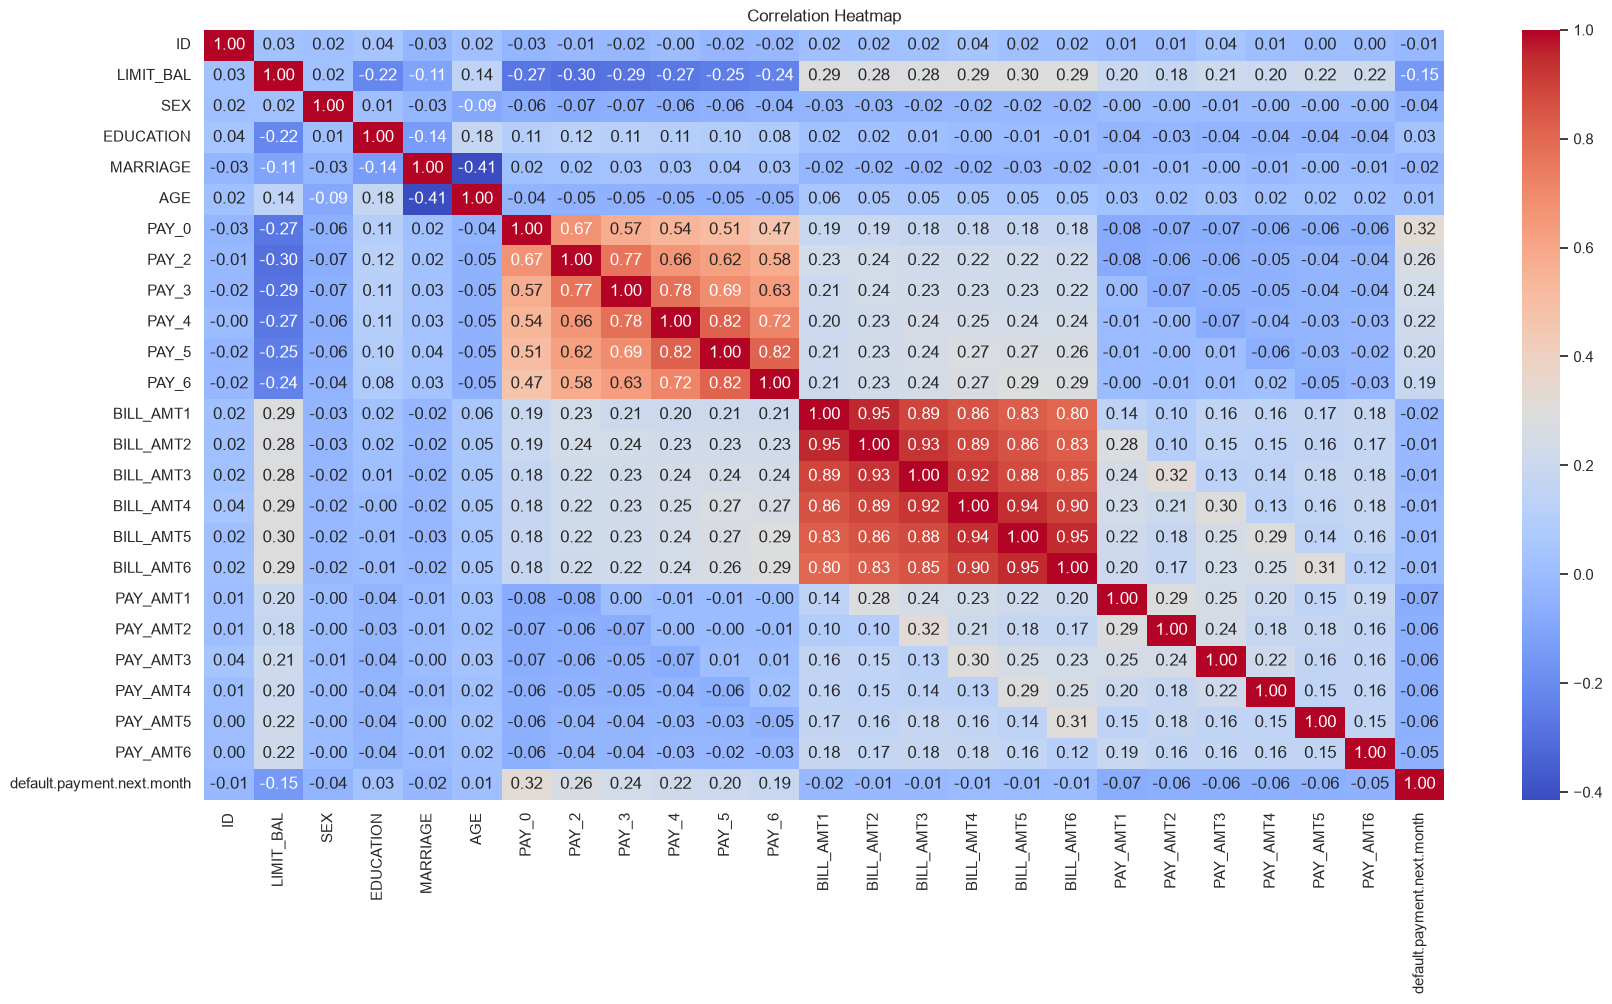

In [11]:
correlation_matrix = df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(correlation_matrix,annot=True,fmt = '.2f',cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

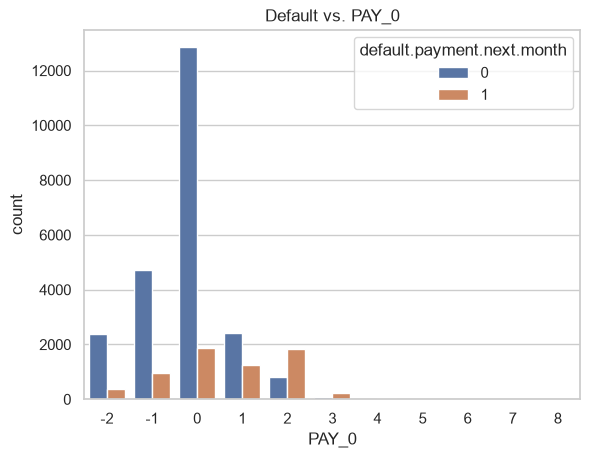

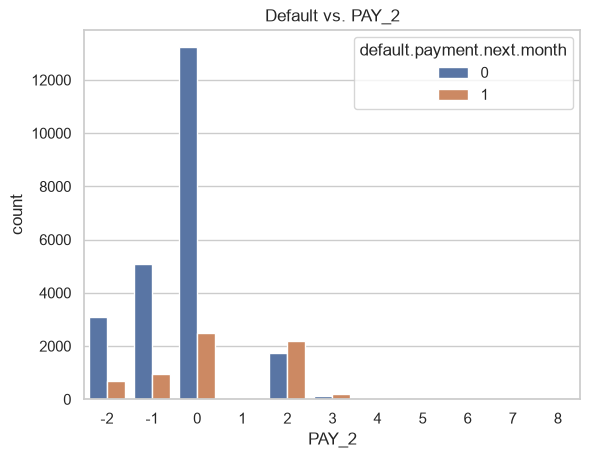

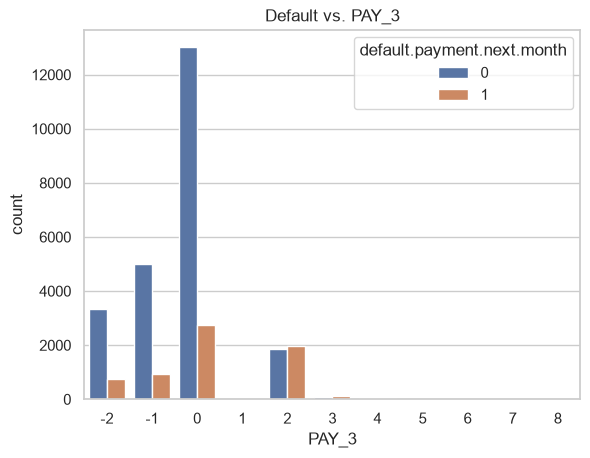

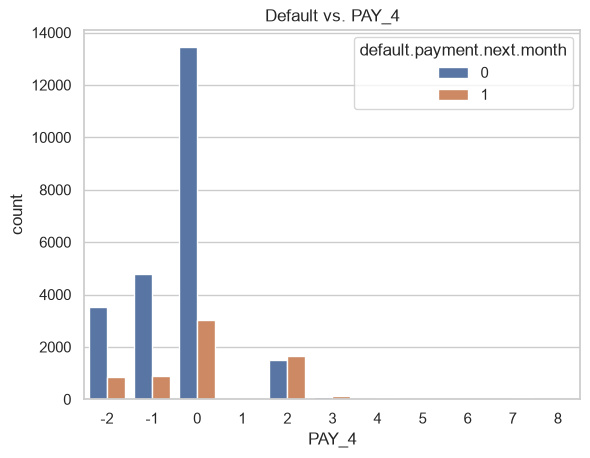

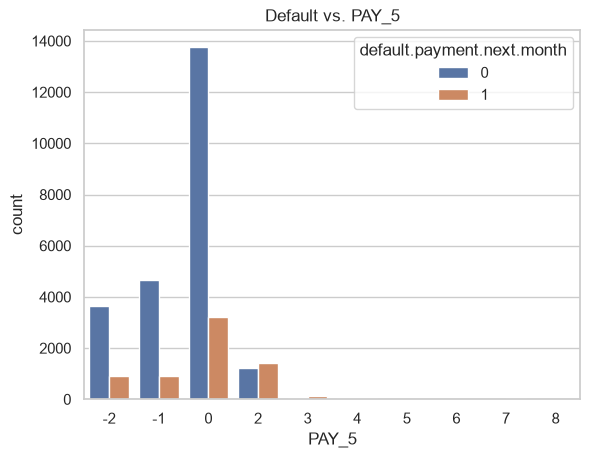

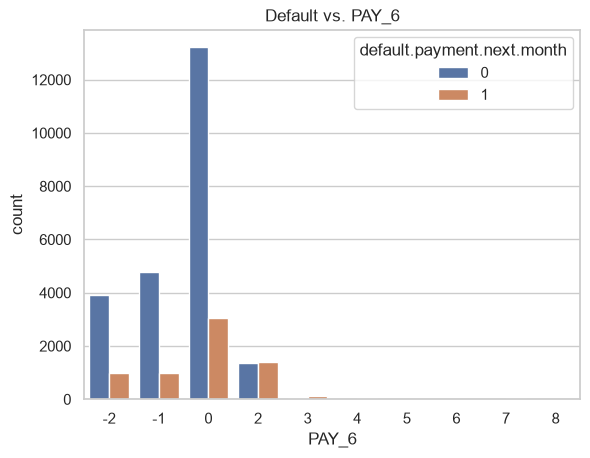

In [12]:
payment_history_columns = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
for col in payment_history_columns:
    sns.countplot(x = col , hue = 'default.payment.next.month',data = df)
    plt.title(f'Default vs. {col}')
    plt.show()

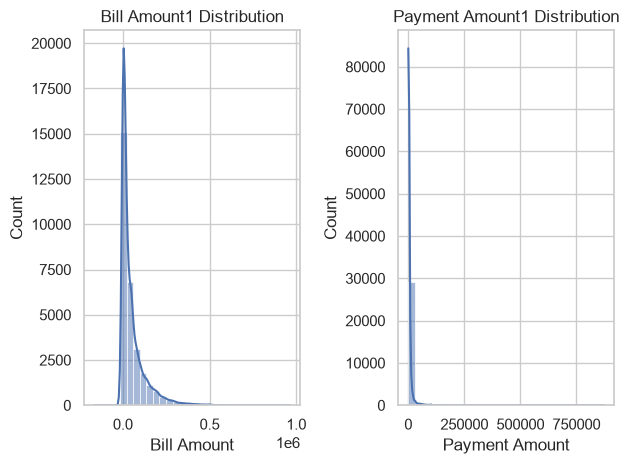

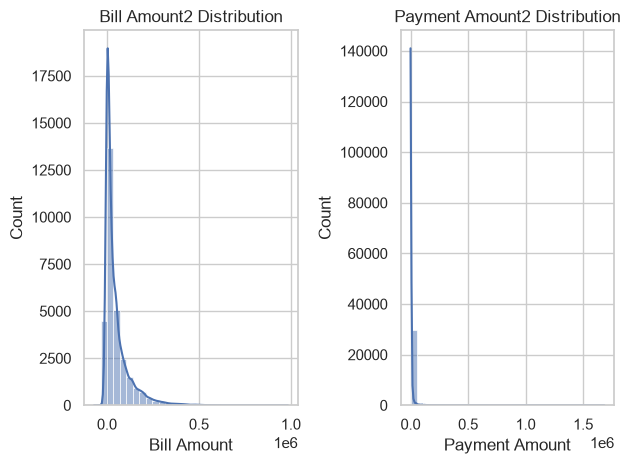

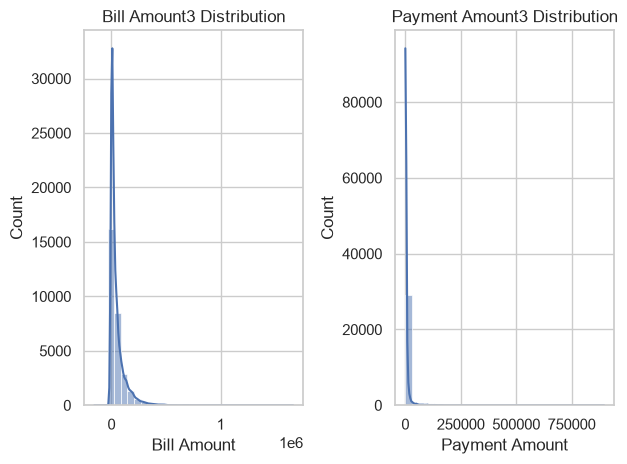

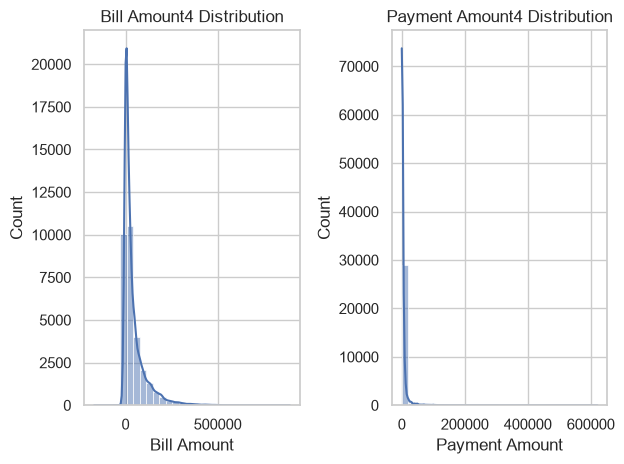

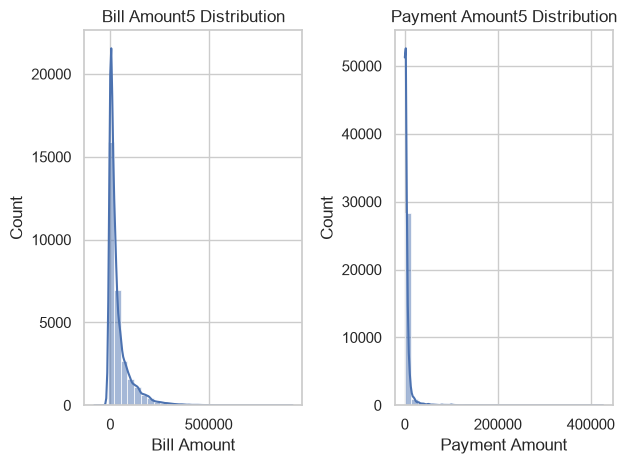

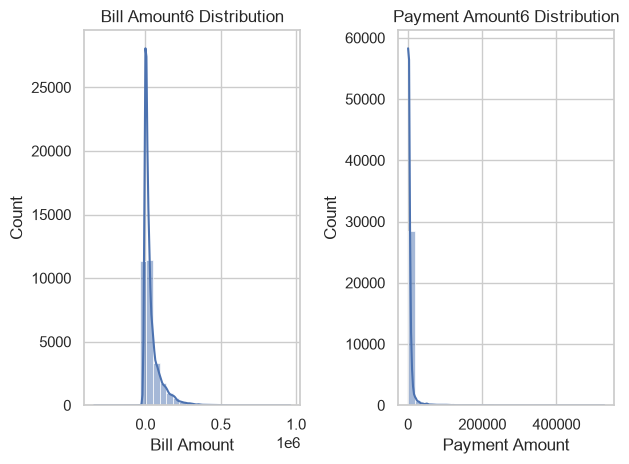

In [13]:
for i in range(1,7):
    plt.Figure(figsize=(30,20))
    plt.subplot(1,2,1)
    sns.histplot(df[f'BILL_AMT{i}'],bins = 30,kde = True)
    plt.title(f'Bill Amount{i} Distribution')
    plt.xlabel('Bill Amount')
    plt.ylabel('Count')

    plt.subplot(1,2,2)
    sns.histplot(df[f'PAY_AMT{i}'],bins = 30,kde = True)
    plt.title(f'Payment Amount{i} Distribution')
    plt.xlabel('Payment Amount')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

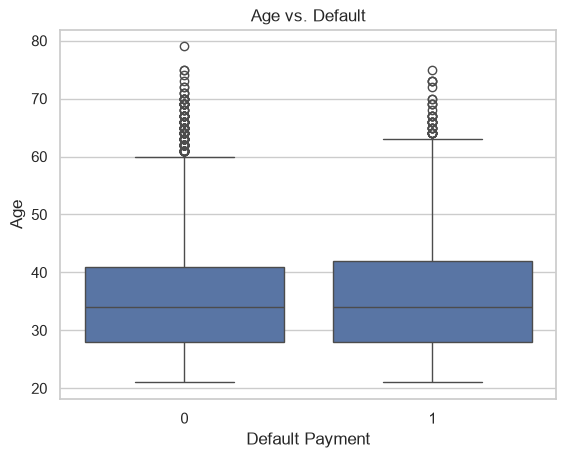

In [14]:
sns.boxplot(x = 'default.payment.next.month',y = 'AGE',data = df)
plt.title('Age vs. Default')
plt.xlabel('Default Payment')
plt.ylabel('Age')
plt.show()

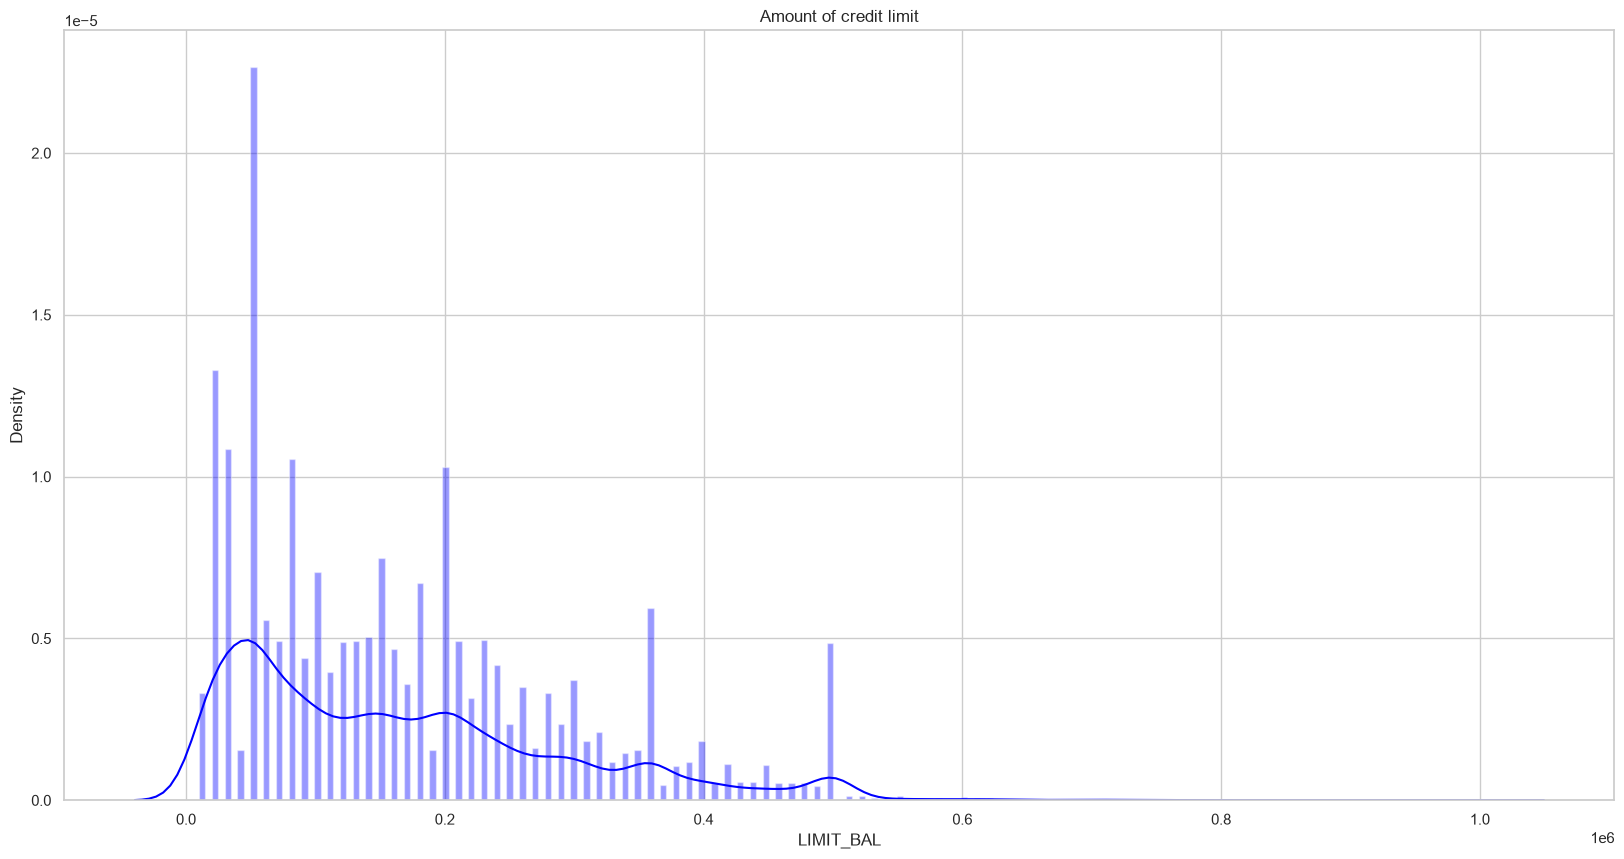

In [15]:
plt.figure(figsize = (20,10))
plt.title('Amount of credit limit')
sns.distplot(df['LIMIT_BAL'],kde = True,bins = 200,color = 'blue')
plt.show()

In [16]:
df['LIMIT_BAL'].value_counts().head(5)

LIMIT_BAL
50000.0     3365
20000.0     1976
30000.0     1610
80000.0     1567
200000.0    1528
Name: count, dtype: int64

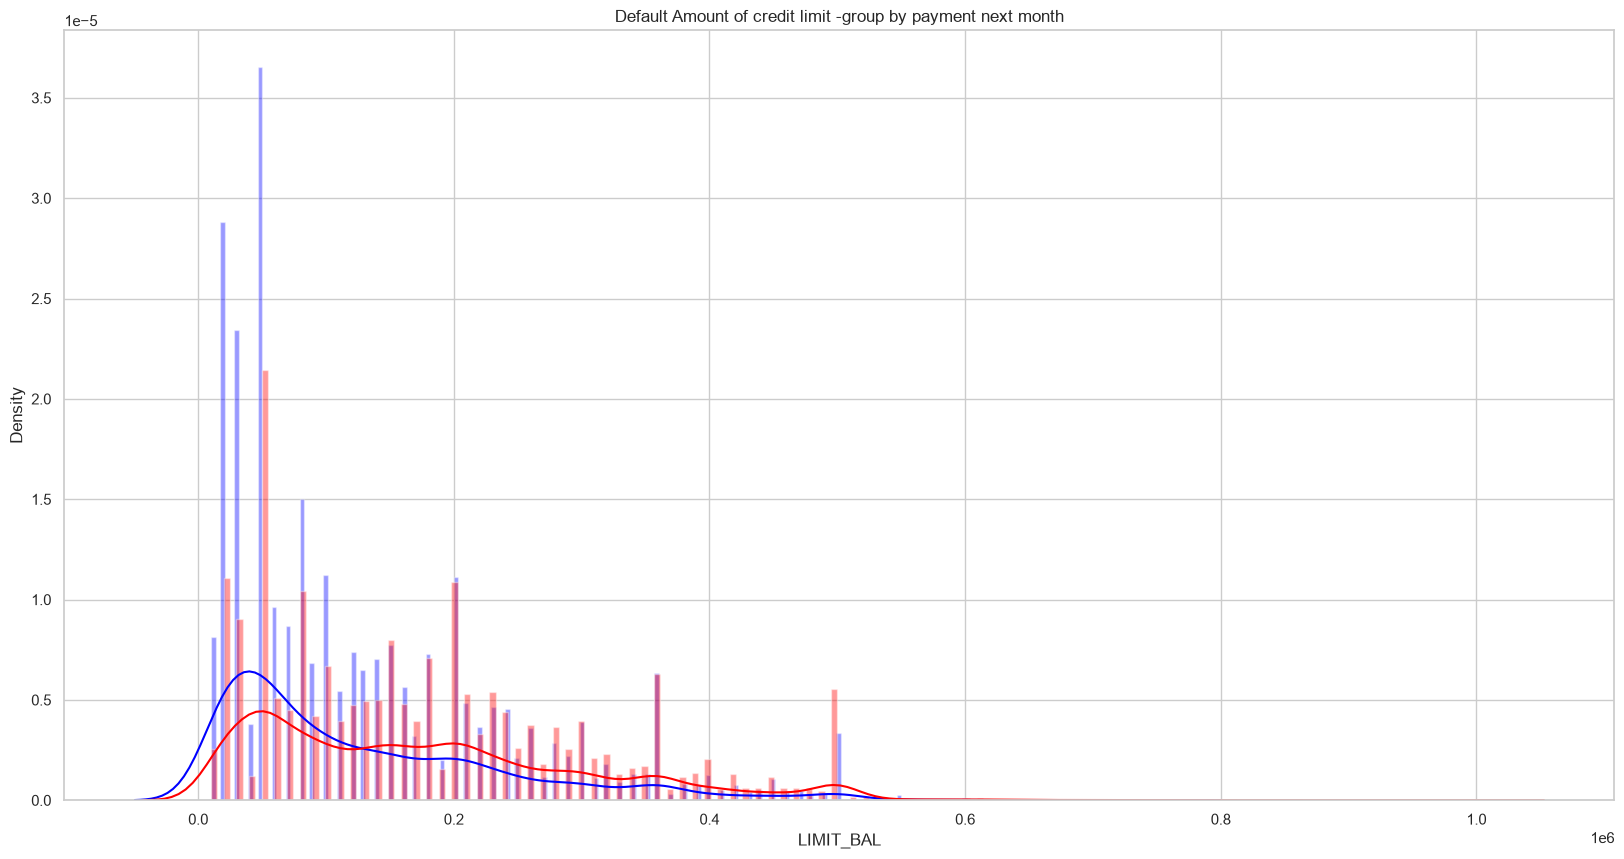

In [17]:
class_0 = df.loc[df['default.payment.next.month'] == 0]['LIMIT_BAL']
class_1 = df.loc[df['default.payment.next.month'] == 1]['LIMIT_BAL']

plt.figure(figsize = (20,10))
plt.title('Default Amount of credit limit -group by payment next month')
sns.distplot(class_1,kde = True,bins = 200,color = 'blue')
sns.distplot(class_0,kde = True,bins = 200,color = 'red')
plt.show()

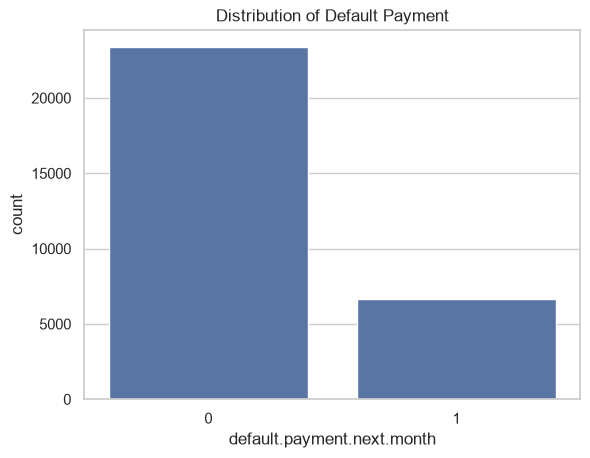

In [18]:
sns.countplot(x = 'default.payment.next.month',data = df)
plt.title('Distribution of Default Payment')
plt.show()

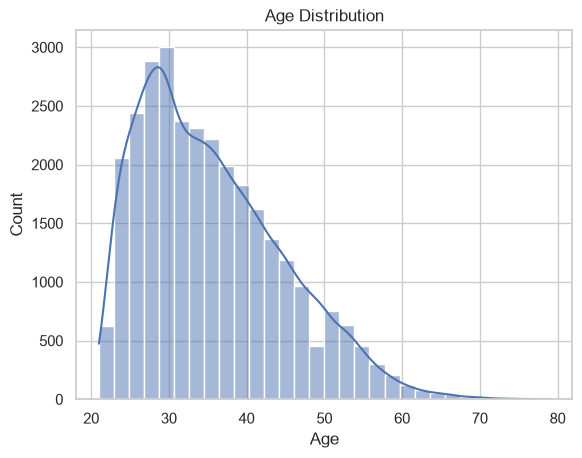

In [19]:
sns.histplot(df['AGE'],bins = 30,kde = True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

<Axes: >

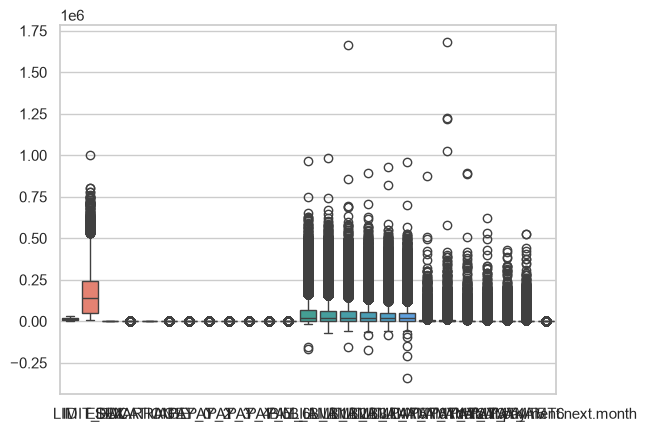

In [20]:
plt.Figure(figsize=(30,10))
sns.boxplot(data = df)

In [21]:
outlier_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

outlier_rows = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_rows.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": int(mask.sum()),
        "Outlier %": round(mask.mean() * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows)
display(outlier_summary)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,LIMIT_BAL,50000.00,240000.00,-235000.000,525000.000,167,0.56
1,AGE,28.00,41.00,8.500,60.500,272,0.91
2,BILL_AMT1,3558.75,67091.00,-91739.625,162389.375,2400,8.00
3,BILL_AMT2,2984.75,64006.25,-88547.500,155538.500,2395,7.98
4,BILL_AMT3,2666.25,60164.75,-83581.500,146412.500,2469,8.23
5,BILL_AMT4,2326.75,54506.00,-75942.125,132774.875,2622,8.74
6,BILL_AMT5,1763.00,50190.50,-70878.250,122831.750,2725,9.08
7,BILL_AMT6,1256.00,49198.25,-70657.375,121111.625,2693,8.98
8,PAY_AMT1,1000.00,5006.00,-5009.000,11015.000,2745,9.15
9,PAY_AMT2,833.00,5000.00,-5417.500,11250.500,2714,9.05


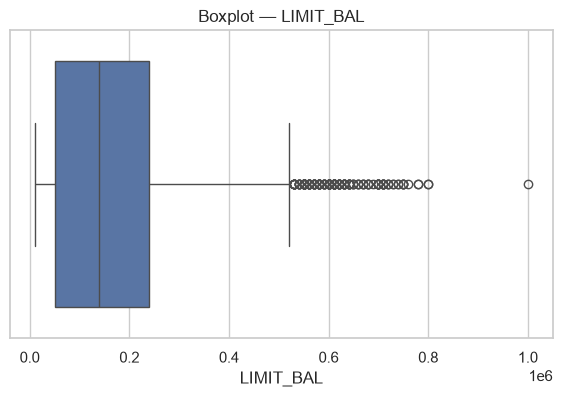

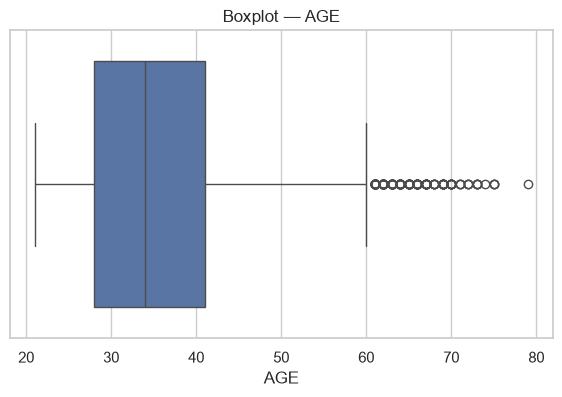

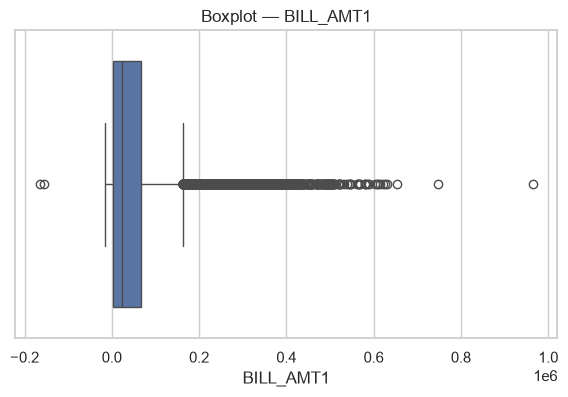

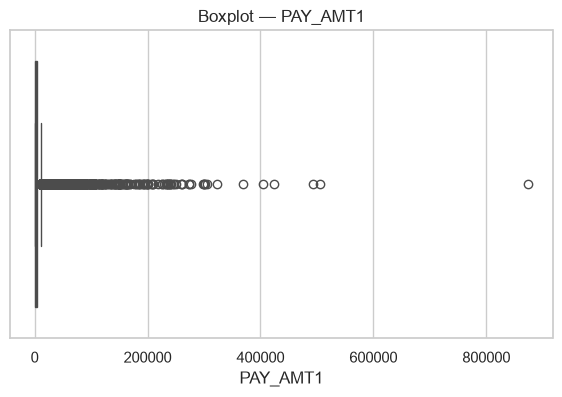

In [22]:
plot_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

for col in plot_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot — {col}")
    plt.show()

In [23]:
df_model = df.copy()
df_model = df_model.drop(columns=["ID"])

df_model["EDUCATION"] = df_model["EDUCATION"].replace({
    0: 5,
    6: 5
})
df_model["MARRIAGE"] = df_model["MARRIAGE"].replace({
    0: 3
})

print("New shape:", df_model.shape)
display(df_model.head())


New shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [24]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(int)

cat_cols = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("\nNumerical columns:", num_cols)


Categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Numerical columns: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [25]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full,test_size=0.20,stratify=y_train_full,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

print("\nTarget distribution:")
print("Train:", y_train.value_counts(normalize=True))
print("Valid:", y_valid.value_counts(normalize=True))
print("Test :", y_test.value_counts(normalize=True))

X_train: (19200, 23)
X_valid: (4800, 23)
X_test : (6000, 23)

Target distribution:
Train: default.payment.next.month
0    0.778802
1    0.221198
Name: proportion, dtype: float64
Valid: default.payment.next.month
0    0.77875
1    0.22125
Name: proportion, dtype: float64
Test : default.payment.next.month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [26]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

logistic_model

In [28]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)
prob_lr = logistic_model.predict_proba(X_valid)[:, 1]



knn_model

In [29]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=25,
        weights="distance",
        metric="minkowski",
        p=2,
        n_jobs=-1
    ))
])

knn_model.fit(X_train, y_train)
prob_knn = knn_model.predict_proba(X_valid)[:, 1]



svm_model

In [30]:
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        C=1.0,
        kernel="rbf",
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_model.fit(X_train, y_train)
prob_svm = svm_model.predict_proba(X_valid)[:, 1]



xgb_model

In [42]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),

    ("model", XGBClassifier(
        n_estimators=1500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=5,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=3,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

prob_xgb = xgb_model.predict_proba(X_valid)[:, 1]



catboost_model

In [37]:
from catboost import CatBoostClassifier

cat_feature_indices = [X.columns.get_loc(c) for c in cat_cols]

catboost_model = CatBoostClassifier(
    iterations=2000,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False,
    thread_count=-1
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=150,
    verbose=False
)

prob_cat = catboost_model.predict_proba(X_valid)[:, 1]



ROC-AUC: 0.7793965170655324
PR-AUC: 0.5426241624624303


In [ ]:
thresholds = np.arange(0.10, 0.71, 0.01)

threshold_results = []

for threshold in thresholds:

    pred = (prob_cat >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred, zero_division=0),
        "Recall": recall_score(y_valid, pred, zero_division=0),
        "F1": f1_score(y_valid, pred, zero_division=0)
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(threshold_results)

# Select threshold with maximum F1
best = threshold_df.loc[threshold_df["F1"].idxmax()]

best_threshold = float(best["Threshold"])

print("Best Threshold:", round(best_threshold, 3))
print("Best F1:", round(best["F1"], 4))
print("Precision:", round(best["Precision"], 4))
print("Recall:", round(best["Recall"], 4))
print("Accuracy:", round(best["Accuracy"], 4))

Best Threshold: 0.28
Best F1: 0.5414
Precision: 0.5262
Recall: 0.5574
Accuracy: 0.791


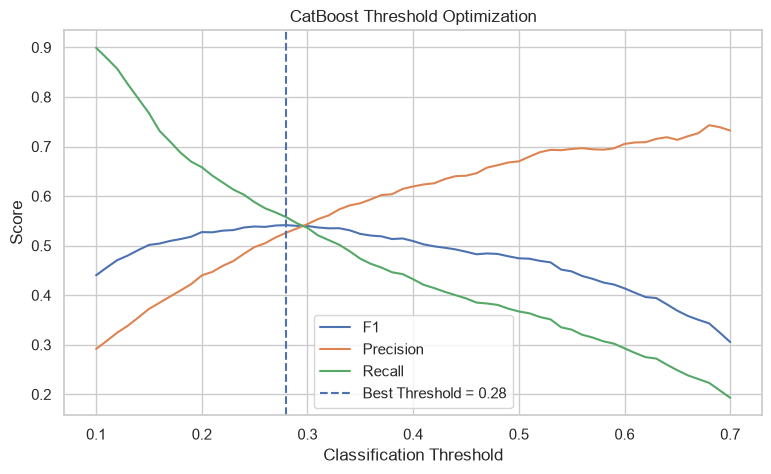

In [40]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("CatBoost Threshold Optimization")
plt.legend()
plt.show()

In [43]:
def evaluate_model(y_true, probability, threshold=0.50):
    prediction = (probability >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability)
    }

validation_probabilities = {
    "Logistic Regression": prob_lr,
    "KNN": prob_knn,
    "SVM": prob_svm,
    "XGBoost": prob_xgb,
    "CatBoost": prob_cat
}

validation_results = []

for name, prob in validation_probabilities.items():
    metrics = evaluate_model(y_valid, prob, threshold=0.50)
    metrics["Model"] = name
    validation_results.append(metrics)

validation_results = pd.DataFrame(validation_results)
validation_results = validation_results[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
].sort_values("F1", ascending=False)

display(validation_results.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.7754,0.4935,0.5678,0.5280,0.7594,0.5279
2,SVM,0.8033,0.5696,0.4548,0.5058,0.7567,0.4977
4,CatBoost,0.8200,0.6701,0.3672,0.4745,0.7794,0.5426
3,XGBoost,0.8171,0.6586,0.3597,0.4653,0.7735,0.5341
1,KNN,0.8069,0.6452,0.2825,0.3929,0.7375,0.4942


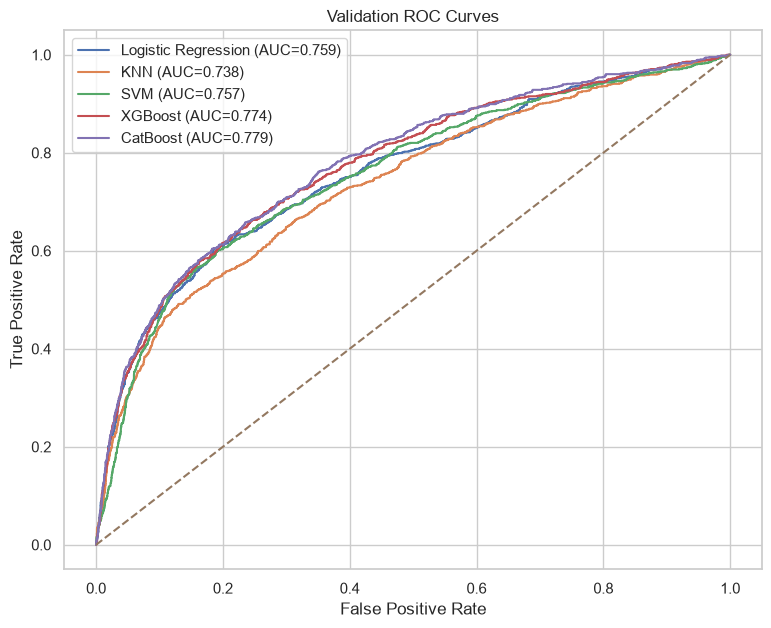

In [44]:
plt.figure(figsize=(9,7))

for name, prob in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(y_valid, prob)
    auc = roc_auc_score(y_valid, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.show()


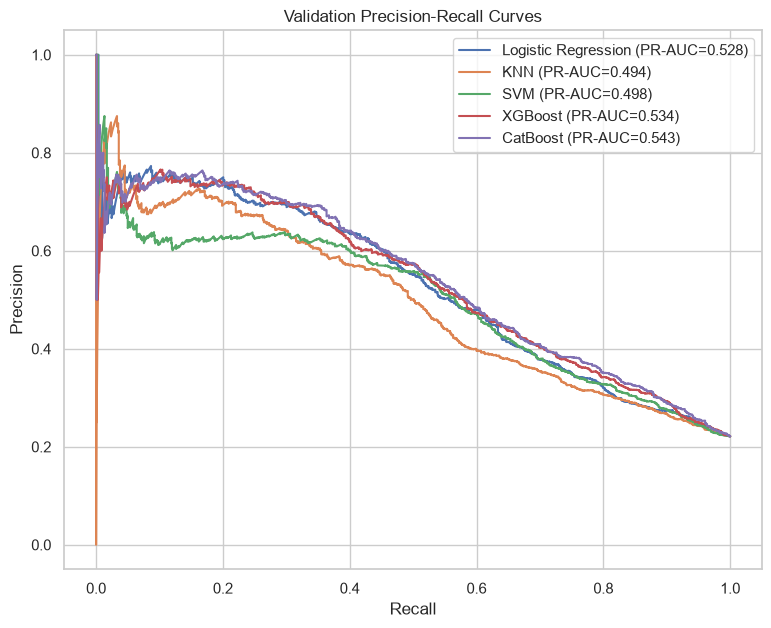

In [45]:
plt.figure(figsize=(9,7))

for name, prob in validation_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_valid, prob)
    ap = average_precision_score(y_valid, prob)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.show()


In [50]:
best_model_row = validation_results.loc[
    validation_results["ROC-AUC"].idxmax()
]

best_model_name = best_model_row["Model"]

print("FINAL MODEL:", best_model_name)
print("Accuracy :", round(best_model_row["Accuracy"], 4))
print("Precision:", round(best_model_row["Precision"], 4))
print("Recall   :", round(best_model_row["Recall"], 4))
print("F1       :", round(best_model_row["F1"], 4))
print("ROC-AUC  :", round(best_model_row["ROC-AUC"], 4))
print("PR-AUC   :", round(best_model_row["PR-AUC"], 4))

FINAL MODEL: CatBoost
Accuracy : 0.82
Precision: 0.6701
Recall   : 0.3672
F1       : 0.4745
ROC-AUC  : 0.7794
PR-AUC   : 0.5426


In [51]:
import os
import joblib

MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)

models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "SVM": svm_model,
    "XGBoost": xgb_model,
    "CatBoost": catboost_model
}

model_paths = {}

for model_name, model in models.items():

    filename = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    path = os.path.join(
        MODEL_DIR,
        filename + ".pkl"
    )

    joblib.dump(model, path)
    model_paths[model_name] = path

    print(f"{model_name} saved → {path}")


joblib.dump(
    preprocessor,
    os.path.join(
        MODEL_DIR,
        "preprocessor.pkl"
    )
)
if "best_model_name" in globals():

    joblib.dump(
        best_model_name,
        os.path.join(
            MODEL_DIR,
            "best_model_name.pkl"
        )
    )

    print(
        f"Best model information saved → "
        f"{MODEL_DIR}/best_model_name.pkl"
    )

if "best_threshold" in globals():
    joblib.dump(
        best_threshold,
        os.path.join(
            MODEL_DIR,
            "best_threshold.pkl"
        )
    )

    print(
        f"Best threshold saved → "
        f"{MODEL_DIR}/best_threshold.pkl"
    )


Logistic Regression saved → saved_models\logistic_regression.pkl
KNN saved → saved_models\knn.pkl
SVM saved → saved_models\svm.pkl
XGBoost saved → saved_models\xgboost.pkl
CatBoost saved → saved_models\catboost.pkl
Best model information saved → saved_models/best_model_name.pkl
Best threshold saved → saved_models/best_threshold.pkl
